# A 题第四问：规则约束与 Dirichlet-Multinomial Mixture 的水质风险评价

本 notebook 使用全部可用出厂水浊度 `NTU` 数据训练典型模式识别模型，并对
**2026-01-01 至 2026-03-31** 的水质进行日尺度风险评价。

核心思路：

1. 以国标 `NTU <= 1` 为不可放宽的硬约束；
2. 提取每日超标幅度、超标比例和连续超标时长；
3. 用确定性规则得到安全、低风险、中风险和高风险；
4. 将每日四类单点状态计数输入 Dirichlet-Multinomial Mixture（DMM）；
5. 比较 `K=2,...,6` 的 BIC、AIC、交叉验证对数似然和有效簇数；
6. DMM 只允许对规则等级进行审慎的**向上修正**，不下调安全日或高风险日。

> 数据说明：2026 年 2 月出厂水 `NTU` 仅 1 天有有效记录，其余 27 天缺失。
> 缺测日保留为“数据缺失”，不会被误判为安全，也不进入四类风险占比的分母。

## 1. 环境、参数与输出目录

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import gammaln, logsumexp, digamma
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
TARGET_COL = "NTU"
STANDARD_LIMIT = 1.0
POINT_THRESHOLDS = (1.0, 1.2, 1.5)
STATE_NAMES = ["safe", "low", "mid", "high"]
STATE_NAMES_CN = ["安全点", "轻微异常点", "中度异常点", "严重异常点"]
RISK_ORDER = ["安全", "低风险", "中风险", "高风险"]
RISK_TO_INT = {name: i for i, name in enumerate(RISK_ORDER)}
Q1_START = pd.Timestamp("2026-01-01")
Q1_END = pd.Timestamp("2026-03-31")
EXPECTED_POINTS_PER_DAY = 12

def locate_project_root():
    cwd = Path.cwd().resolve()
    for root in [cwd] + list(cwd.parents):
        if (root / "data" / "merged.xlsx").exists():
            return root
    raise FileNotFoundError("未找到 data/merged.xlsx，请从项目目录或其子目录运行。")

PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "merged.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "codes" / "p4" / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("项目目录：", PROJECT_ROOT)
print("数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)

项目目录： /Users/jinyu/workspace/2026亚太杯
数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
输出目录： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs


## 2. 读取与整理全部 NTU 数据

使用 `merged.xlsx` 中未经标准化、未经截断的原始 `NTU`。以数据中的 `DATE`
作为日分组标签，同日内按 `TIME` 排序。原始记录的时间间隔为 2 小时。

In [2]:
raw = pd.read_excel(DATA_PATH)
required = {"DATE", "TIME", TARGET_COL}
missing_cols = required.difference(raw.columns)
if missing_cols:
    raise ValueError(f"缺少必要字段：{sorted(missing_cols)}")

data = raw[["DATE", "TIME", TARGET_COL]].copy()
data["DATE"] = pd.to_datetime(data["DATE"], errors="coerce").dt.normalize()
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors="coerce")

time_text = data["TIME"].astype(str).str.strip()
time_delta = pd.to_timedelta(time_text, errors="coerce")
data["DATETIME"] = data["DATE"] + time_delta
data = data.sort_values(["DATE", "DATETIME"], na_position="last").reset_index(drop=True)

audit = pd.DataFrame({
    "指标": [
        "原始行数", "日期数", "日期范围起点", "日期范围终点",
        "NTU 有效点数", "NTU 缺失点数", "NTU 超标点数", "NTU 最大值"
    ],
    "数值": [
        len(data), data["DATE"].nunique(), data["DATE"].min().date(), data["DATE"].max().date(),
        data[TARGET_COL].notna().sum(), data[TARGET_COL].isna().sum(),
        (data[TARGET_COL] > STANDARD_LIMIT).sum(), data[TARGET_COL].max()
    ]
})
display(audit)

ntu_distribution = data[TARGET_COL].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("NTU")
display(ntu_distribution)

,指标,数值
0,原始行数,5460
1,日期数,456
2,日期范围起点,2025-01-01
3,日期范围终点,2026-04-01
4,NTU 有效点数,5124
5,NTU 缺失点数,336
6,NTU 超标点数,179
7,NTU 最大值,11.9000


,NTU
count,5124.0000
mean,0.4458
std,0.6163
min,0.0800
1%,0.1100
5%,0.1300
25%,0.2000
50%,0.3100
75%,0.5100
90%,0.6900


## 3. 单点风险状态

In [3]:
def assign_point_state(x):
    if pd.isna(x):
        return pd.NA
    if x <= 1.0:
        return "safe"
    if x <= 1.2:
        return "low"
    if x <= 1.5:
        return "mid"
    return "high"

data["point_state"] = data[TARGET_COL].map(assign_point_state)
data["is_exceed"] = data[TARGET_COL] > STANDARD_LIMIT
data["exceed_amp"] = (data[TARGET_COL] - STANDARD_LIMIT).clip(lower=0)

point_state_summary = (
    data.dropna(subset=["point_state"])
    .groupby("point_state", observed=False)
    .size()
    .reindex(STATE_NAMES, fill_value=0)
    .rename("观测点数")
    .to_frame()
)
point_state_summary["占比"] = point_state_summary["观测点数"] / point_state_summary["观测点数"].sum()
point_state_summary.index = STATE_NAMES_CN
display(point_state_summary)

,观测点数,占比
安全点,4945,0.9651
轻微异常点,25,0.0049
中度异常点,24,0.0047
严重异常点,130,0.0254


## 4. 每日风险特征

除题目要求的特征外，同时输出：

- `max_continuous_exceed_points`：最长连续超标观测点数；
- `max_continuous_exceed_hours`：按 2 小时间隔换算的持续时长；
- `data_coverage`：有效观测点数 / 12，用于识别不完整日期。

In [4]:
def longest_true_run(values):
    best = current = 0
    for value in values:
        if bool(value):
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best

valid = data.dropna(subset=["DATE", TARGET_COL]).copy()

daily_records = []
for date, group in valid.groupby("DATE", sort=True):
    group = group.sort_values("DATETIME")
    exceed = group["is_exceed"].to_numpy(dtype=bool)
    exceed_amp = group.loc[group["is_exceed"], "exceed_amp"]
    run_points = longest_true_run(exceed)

    state_counts = (
        group["point_state"].value_counts()
        .reindex(STATE_NAMES, fill_value=0)
        .astype(int)
    )
    daily_records.append({
        "DATE": date,
        "n_points": len(group),
        "data_coverage": len(group) / EXPECTED_POINTS_PER_DAY,
        "mean_NTU": group[TARGET_COL].mean(),
        "max_NTU": group[TARGET_COL].max(),
        "min_NTU": group[TARGET_COL].min(),
        "std_NTU": group[TARGET_COL].std(ddof=0),
        "exceed_count": int(exceed.sum()),
        "exceed_ratio": exceed.mean(),
        "max_exceed_amp": group["exceed_amp"].max(),
        "mean_exceed_amp": exceed_amp.mean() if len(exceed_amp) else 0.0,
        "max_continuous_exceed_points": run_points,
        "max_continuous_exceed_hours": run_points * 2.0,
        "n_safe": state_counts["safe"],
        "n_low": state_counts["low"],
        "n_mid": state_counts["mid"],
        "n_high": state_counts["high"],
    })

daily = pd.DataFrame(daily_records).sort_values("DATE").reset_index(drop=True)
daily["is_complete_day"] = daily["n_points"].eq(EXPECTED_POINTS_PER_DAY)

print("可用于 DMM 的有效日期数：", len(daily))
print("完整 12 点日期数：", daily["is_complete_day"].sum())
display(daily.head())

可用于 DMM 的有效日期数： 429
完整 12 点日期数： 425


,DATE,n_points,data_coverage,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,exceed_ratio,max_exceed_amp,mean_exceed_amp,max_continuous_exceed_points,max_continuous_exceed_hours,n_safe,n_low,n_mid,n_high,is_complete_day
0,2025-01-01,9,0.7500,0.1144,0.1200,0.1100,0.0050,0,0.0000,0.0000,0.0000,0,0.0000,9,0,0,0,False
1,2025-01-02,12,1.0000,0.1192,0.1300,0.1000,0.0095,0,0.0000,0.0000,0.0000,0,0.0000,12,0,0,0,True
2,2025-01-03,12,1.0000,0.1150,0.1200,0.1100,0.0050,0,0.0000,0.0000,0.0000,0,0.0000,12,0,0,0,True
3,2025-01-04,12,1.0000,0.1250,0.1500,0.1100,0.0112,0,0.0000,0.0000,0.0000,0,0.0000,12,0,0,0,True
4,2025-01-05,12,1.0000,0.1208,0.1300,0.1100,0.0076,0,0.0000,0.0000,0.0000,0,0.0000,12,0,0,0,True


## 5. 基于规则的初始风险等级

In [5]:
def classify_rule(row):
    if row["exceed_count"] == 0:
        return "安全"

    high = (
        (row["exceed_ratio"] > 0.50)
        or (row["max_NTU"] > 1.50)
        or (row["max_continuous_exceed_points"] > 5)
    )
    if high:
        return "高风险"

    low = (
        (row["exceed_ratio"] <= 0.20)
        and (row["max_NTU"] <= 1.20)
        and (row["max_continuous_exceed_points"] <= 2)
    )
    if low:
        return "低风险"

    # 有超标且未落入安全、低风险或高风险时，按中风险处理。
    return "中风险"

daily["rule_risk"] = daily.apply(classify_rule, axis=1)
rule_summary_all = (
    daily["rule_risk"].value_counts()
    .reindex(RISK_ORDER, fill_value=0)
    .rename("天数")
    .to_frame()
)
display(rule_summary_all)

,天数
rule_risk,
安全,390
低风险,2
中风险,9
高风险,28


## 6. DMM 数学模型与估计

对第 \(i\) 天的四状态计数向量

\[
\mathbf y_i=(n_{safe,i},n_{low,i},n_{mid,i},n_{high,i})
\]

假设其来自 \(K\) 个 Dirichlet-Multinomial 分量之一。EM 的 E 步计算后验责任度，
M 步更新混合权重，并用加权固定点迭代估计每个分量的 Dirichlet 参数。

实现包含多次初始化，以降低局部最优影响。模型选择参数数目为
\(p=4K+(K-1)\)。

In [6]:
def dm_logpmf(Y, alpha):
    Y = np.asarray(Y, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    n = Y.sum(axis=1)
    a0 = alpha.sum()
    return (
        gammaln(n + 1)
        - gammaln(Y + 1).sum(axis=1)
        + gammaln(a0)
        - gammaln(n + a0)
        + (gammaln(Y + alpha) - gammaln(alpha)).sum(axis=1)
    )

def update_alpha_fixed_point(Y, weights, alpha, max_iter=80, tol=1e-6):
    Y = np.asarray(Y, dtype=float)
    weights = np.asarray(weights, dtype=float)
    n = Y.sum(axis=1)
    alpha = np.clip(np.asarray(alpha, dtype=float), 1e-4, 1e4)

    if weights.sum() < 1e-8:
        return alpha

    for _ in range(max_iter):
        a0 = alpha.sum()
        numerator = (
            weights[:, None] * (digamma(Y + alpha) - digamma(alpha))
        ).sum(axis=0)
        denominator = (
            weights * (digamma(n + a0) - digamma(a0))
        ).sum()
        updated = np.clip(alpha * numerator / max(denominator, 1e-12), 1e-4, 1e4)
        if np.max(np.abs(np.log(updated / alpha))) < tol:
            alpha = updated
            break
        alpha = 0.5 * alpha + 0.5 * updated
    return alpha

class DMM:
    def __init__(
        self, n_components, random_state=42, n_init=5,
        max_iter=180, tol=1e-7
    ):
        self.n_components = n_components
        self.random_state = random_state
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol

    def _initial_responsibilities(self, Y, rng):
        severity = (Y @ np.arange(Y.shape[1])) / np.maximum(Y.sum(axis=1), 1)
        cuts = np.quantile(
            severity, np.linspace(0, 1, self.n_components + 1)
        )
        noisy = severity + rng.normal(0, 0.015, len(Y))
        labels = np.digitize(noisy, cuts[1:-1], right=False)
        if len(np.unique(labels)) < self.n_components:
            labels = rng.integers(0, self.n_components, size=len(Y))
        resp = np.eye(self.n_components)[labels] * 0.95
        resp += 0.05 / self.n_components
        return resp

    def fit(self, Y):
        Y = np.asarray(Y, dtype=float)
        master_rng = np.random.default_rng(self.random_state)
        best = None

        for init_id in range(self.n_init):
            rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))
            resp = self._initial_responsibilities(Y, rng)
            base = np.array([20.0, 0.5, 0.3, 0.2])
            alphas = np.tile(base, (self.n_components, 1))
            alphas *= rng.lognormal(0, 0.5, alphas.shape)
            previous_ll = -np.inf

            for iteration in range(self.max_iter):
                mix = resp.sum(axis=0) + 1e-6
                mix = mix / mix.sum()
                for k in range(self.n_components):
                    alphas[k] = update_alpha_fixed_point(
                        Y, resp[:, k], alphas[k]
                    )

                log_joint = np.column_stack([
                    np.log(mix[k]) + dm_logpmf(Y, alphas[k])
                    for k in range(self.n_components)
                ])
                row_norm = logsumexp(log_joint, axis=1)
                ll = row_norm.sum()
                resp = np.exp(log_joint - row_norm[:, None])

                if (
                    np.isfinite(previous_ll)
                    and abs(ll - previous_ll) <= self.tol * (1 + abs(previous_ll))
                ):
                    break
                previous_ll = ll

            candidate = {
                "log_likelihood": ll,
                "weights": mix.copy(),
                "alphas": alphas.copy(),
                "responsibilities": resp.copy(),
                "n_iter": iteration + 1,
                "init_id": init_id,
            }
            if best is None or candidate["log_likelihood"] > best["log_likelihood"]:
                best = candidate

        self.log_likelihood_ = best["log_likelihood"]
        self.weights_ = best["weights"]
        self.alphas_ = best["alphas"]
        self.responsibilities_ = best["responsibilities"]
        self.n_iter_ = best["n_iter"]
        self.labels_ = self.responsibilities_.argmax(axis=1)
        return self

    def score_samples(self, Y):
        Y = np.asarray(Y, dtype=float)
        log_joint = np.column_stack([
            np.log(self.weights_[k]) + dm_logpmf(Y, self.alphas_[k])
            for k in range(self.n_components)
        ])
        return logsumexp(log_joint, axis=1)

    def predict_proba(self, Y):
        Y = np.asarray(Y, dtype=float)
        log_joint = np.column_stack([
            np.log(self.weights_[k]) + dm_logpmf(Y, self.alphas_[k])
            for k in range(self.n_components)
        ])
        return np.exp(log_joint - logsumexp(log_joint, axis=1)[:, None])

    def predict(self, Y):
        return self.predict_proba(Y).argmax(axis=1)

    @property
    def component_proportions_(self):
        return self.alphas_ / self.alphas_.sum(axis=1, keepdims=True)

## 7. K=2–6：BIC、AIC、交叉验证与有效簇数

In [7]:
count_cols = ["n_safe", "n_low", "n_mid", "n_high"]
Y = daily[count_cols].to_numpy(dtype=int)

def cross_validated_loglik(Y, k, n_splits=3):
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(Y), start=1):
        model = DMM(
            k, random_state=RANDOM_STATE + fold,
            n_init=2, max_iter=120
        ).fit(Y[train_idx])
        fold_scores.append(model.score_samples(Y[test_idx]).mean())
    return float(np.mean(fold_scores)), float(np.std(fold_scores))

model_candidates = {}
comparison_rows = []

for k in range(2, 7):
    model = DMM(
        k, random_state=RANDOM_STATE + k,
        n_init=6, max_iter=180
    ).fit(Y)
    model_candidates[k] = model
    n_params = k * len(count_cols) + (k - 1)
    bic = -2 * model.log_likelihood_ + n_params * np.log(len(Y))
    aic = -2 * model.log_likelihood_ + 2 * n_params
    cv_mean, cv_std = cross_validated_loglik(Y, k)
    hard_sizes = np.bincount(model.labels_, minlength=k)
    effective_clusters = int((hard_sizes >= 3).sum())

    comparison_rows.append({
        "K": k,
        "log_likelihood": model.log_likelihood_,
        "AIC": aic,
        "BIC": bic,
        "CV_mean_loglik_per_day": cv_mean,
        "CV_std": cv_std,
        "effective_clusters_n_ge_3": effective_clusters,
        "smallest_cluster_days": hard_sizes.min(),
        "converged_iterations": model.n_iter_,
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values("K")
display(model_comparison)

,K,log_likelihood,AIC,BIC,CV_mean_loglik_per_day,CV_std,effective_clusters_n_ge_3,smallest_cluster_days,converged_iterations
0,2,-294.9916,607.9831,644.5362,-0.7291,0.1677,2,31,180
1,3,-284.3568,596.7136,653.5740,-0.7064,0.1681,3,9,180
2,4,-275.7162,589.4325,666.6002,-0.7091,0.1827,4,3,180
3,5,-275.5193,599.0387,696.5136,-0.7196,0.1769,5,3,180
4,6,-275.5454,609.0907,726.8730,-0.7291,0.2074,5,0,180


### K 的自动选择原则

先排除存在少于 3 天小簇的退化模型；在剩余模型中计算 BIC、AIC 和交叉验证
对数似然的名次和。名次和最小者作为建议 K；若并列，优先选择较小 K。
这使最终选择同时考虑拟合、复杂度、泛化和簇稳定性。

In [8]:
eligible = model_comparison[
    model_comparison["smallest_cluster_days"] >= 3
].copy()
if eligible.empty:
    eligible = model_comparison.copy()

eligible["rank_BIC"] = eligible["BIC"].rank(method="min", ascending=True)
eligible["rank_AIC"] = eligible["AIC"].rank(method="min", ascending=True)
eligible["rank_CV"] = eligible["CV_mean_loglik_per_day"].rank(
    method="min", ascending=False
)
eligible["rank_sum"] = (
    eligible["rank_BIC"] + eligible["rank_AIC"] + eligible["rank_CV"]
)
selected_k = int(
    eligible.sort_values(["rank_sum", "BIC", "K"]).iloc[0]["K"]
)
dmm = model_candidates[selected_k]

print("最终选择 K =", selected_k)
display(eligible.sort_values(["rank_sum", "BIC", "K"]))

最终选择 K = 3


,K,log_likelihood,AIC,BIC,CV_mean_loglik_per_day,CV_std,effective_clusters_n_ge_3,smallest_cluster_days,converged_iterations,rank_BIC,rank_AIC,rank_CV,rank_sum
1,3,-284.3568,596.7136,653.5740,-0.7064,0.1681,3,9,180,2.0000,2.0000,1.0000,5.0000
2,4,-275.7162,589.4325,666.6002,-0.7091,0.1827,4,3,180,3.0000,1.0000,2.0000,6.0000
0,2,-294.9916,607.9831,644.5362,-0.7291,0.1677,2,31,180,1.0000,4.0000,4.0000,9.0000
3,5,-275.5193,599.0387,696.5136,-0.7196,0.1769,5,3,180,4.0000,3.0000,3.0000,10.0000


## 8. DMM 典型模式解释

In [9]:
proportions = dmm.component_proportions_
severity_weights = np.array([0.0, 1.0, 2.0, 3.0])
component_severity = proportions @ severity_weights
severity_rank = np.argsort(component_severity)

def pattern_name(rank, k):
    if rank == 0:
        return "稳定安全型"
    if rank == k - 1:
        return "严重异常型"
    if k == 3:
        return "持续中度异常型"
    if rank <= (k - 1) / 2:
        return "偶发轻微超标型"
    return "持续中度异常型"

cluster_name_map = {}
cluster_risk_map = {}
cluster_rows = []
hard_sizes = np.bincount(dmm.labels_, minlength=selected_k)

for rank, cluster_id in enumerate(severity_rank):
    name = pattern_name(rank, selected_k)
    cluster_name_map[int(cluster_id)] = name
    if rank == 0:
        implied_risk = "低风险"
    elif rank == selected_k - 1:
        implied_risk = "高风险"
    else:
        implied_risk = "中风险"
    cluster_risk_map[int(cluster_id)] = implied_risk

    cluster_rows.append({
        "cluster_id": int(cluster_id),
        "pattern_name": name,
        "implied_risk": implied_risk,
        "hard_assignment_days": int(hard_sizes[cluster_id]),
        "mixture_weight": dmm.weights_[cluster_id],
        "safe_share": proportions[cluster_id, 0],
        "low_share": proportions[cluster_id, 1],
        "mid_share": proportions[cluster_id, 2],
        "high_share": proportions[cluster_id, 3],
        "severity_score": component_severity[cluster_id],
        "alpha_concentration": dmm.alphas_[cluster_id].sum(),
    })

cluster_profiles = pd.DataFrame(cluster_rows).sort_values("severity_score")
display(cluster_profiles)

,cluster_id,pattern_name,implied_risk,hard_assignment_days,mixture_weight,safe_share,low_share,mid_share,high_share,severity_score,alpha_concentration
0,1,稳定安全型,低风险,390,0.8159,1.0000,0.0000,0.0000,0.0000,0.0001,11.5641
1,0,持续中度异常型,中风险,30,0.1633,0.9035,0.0257,0.0260,0.0448,0.2121,5.1236
2,2,严重异常型,高风险,9,0.0208,0.0703,0.0253,0.0428,0.8616,2.6957,14.0899


## 9. 规则等级与 DMM 模式融合

In [10]:
posterior = dmm.predict_proba(Y)
daily["dmm_cluster"] = dmm.predict(Y)
daily["dmm_pattern"] = daily["dmm_cluster"].map(cluster_name_map)
daily["dmm_implied_risk"] = daily["dmm_cluster"].map(cluster_risk_map)
daily["dmm_max_probability"] = posterior.max(axis=1)
for k in range(selected_k):
    daily[f"dmm_prob_cluster_{k}"] = posterior[:, k]

def fuse_risk(row):
    rule = row["rule_risk"]
    dmm_level = row["dmm_implied_risk"]

    if rule == "安全":
        return "安全", "安全日保持不变"
    if rule == "高风险":
        return "高风险", "规则高风险不下调"

    if rule == "低风险" and RISK_TO_INT[dmm_level] >= RISK_TO_INT["中风险"]:
        return "中风险", f"DMM 识别为{row['dmm_pattern']}，由低风险上调"

    severe_evidence = (
        (row["max_exceed_amp"] > 0.20)
        or (row["max_continuous_exceed_points"] > 2)
    )
    if (
        rule == "中风险"
        and dmm_level == "高风险"
        and severe_evidence
    ):
        return "高风险", "DMM 严重异常型且存在较大幅度或较长连续超标"

    return rule, "规则与 DMM 一致或证据不足，不修正"

fused = daily.apply(fuse_risk, axis=1, result_type="expand")
daily["final_risk"] = fused[0]
daily["fusion_note"] = fused[1]
daily["was_adjusted"] = daily["final_risk"].ne(daily["rule_risk"])

consistency = pd.crosstab(
    daily["rule_risk"], daily["dmm_implied_risk"],
    rownames=["规则等级"], colnames=["DMM 隐含等级"], margins=True
)
display(consistency)
display(
    daily.loc[daily["was_adjusted"], [
        "DATE", "max_NTU", "exceed_ratio", "max_exceed_amp",
        "max_continuous_exceed_points", "rule_risk", "dmm_pattern",
        "dmm_max_probability", "final_risk", "fusion_note"
    ]]
)

DMM 隐含等级,中风险,低风险,高风险,All
规则等级,,,,
中风险,9,0,0,9
低风险,2,0,0,2
安全,0,390,0,390
高风险,19,0,9,28
All,30,390,9,429


,DATE,max_NTU,exceed_ratio,max_exceed_amp,max_continuous_exceed_points,rule_risk,dmm_pattern,dmm_max_probability,final_risk,fusion_note
350,2025-12-17,1.0600,0.0833,0.0600,1,低风险,持续中度异常型,0.9950,中风险,DMM 识别为持续中度异常型，由低风险上调
354,2025-12-21,1.1500,0.1667,0.1500,2,低风险,持续中度异常型,0.9970,中风险,DMM 识别为持续中度异常型，由低风险上调


## 10. 2026 年近 3 个月风险统计（含缺失日审计）

In [11]:
q1_calendar = pd.DataFrame({
    "DATE": pd.date_range(Q1_START, Q1_END, freq="D")
})
q1 = q1_calendar.merge(daily, on="DATE", how="left")
q1["data_status"] = np.where(q1["n_points"].isna(), "数据缺失", "可评价")

valid_q1 = q1[q1["data_status"].eq("可评价")].copy()
risk_counts = (
    valid_q1["final_risk"].value_counts()
    .reindex(RISK_ORDER, fill_value=0)
)
q1_risk_summary = pd.DataFrame({
    "风险等级": RISK_ORDER,
    "天数": [int(risk_counts[x]) for x in RISK_ORDER],
    "占有效评价日比例": [
        risk_counts[x] / len(valid_q1) if len(valid_q1) else np.nan
        for x in RISK_ORDER
    ],
    "占90个日历日比例": [risk_counts[x] / len(q1) for x in RISK_ORDER],
})

q1_coverage_summary = pd.DataFrame({
    "项目": ["日历日数", "有效评价日数", "缺失日数", "有效覆盖率"],
    "数值": [
        len(q1), len(valid_q1), q1["data_status"].eq("数据缺失").sum(),
        len(valid_q1) / len(q1)
    ]
})

display(q1_coverage_summary)
display(q1_risk_summary)

,项目,数值
0,日历日数,90.0000
1,有效评价日数,63.0000
2,缺失日数,27.0000
3,有效覆盖率,0.7000


,风险等级,天数,占有效评价日比例,占90个日历日比例
0,安全,59,0.9365,0.6556
1,低风险,0,0.0000,0.0000
2,中风险,1,0.0159,0.0111
3,高风险,3,0.0476,0.0333


## 11. 2026 年 3 月每日具体风险等级

In [12]:
march = q1[q1["DATE"].between("2026-03-01", "2026-03-31")].copy()
march_output_cols = [
    "DATE", "data_status", "n_points", "data_coverage",
    "mean_NTU", "max_NTU", "exceed_count", "exceed_ratio",
    "max_exceed_amp", "mean_exceed_amp",
    "max_continuous_exceed_points", "max_continuous_exceed_hours",
    "rule_risk", "dmm_pattern", "dmm_max_probability",
    "final_risk", "fusion_note"
]
march_results = march[march_output_cols]
display(march_results)

,DATE,data_status,n_points,data_coverage,mean_NTU,max_NTU,exceed_count,exceed_ratio,max_exceed_amp,mean_exceed_amp,max_continuous_exceed_points,max_continuous_exceed_hours,rule_risk,dmm_pattern,dmm_max_probability,final_risk,fusion_note
59,2026-03-01,可评价,9.0000,0.7500,0.4511,0.4800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.8966,安全,安全日保持不变
60,2026-03-02,可评价,12.0000,1.0000,0.4683,0.4900,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
61,2026-03-03,可评价,12.0000,1.0000,0.4867,0.5100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
62,2026-03-04,可评价,12.0000,1.0000,0.5067,0.5200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
63,2026-03-05,可评价,12.0000,1.0000,0.5217,0.5600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
64,2026-03-06,可评价,12.0000,1.0000,0.5350,0.5600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
65,2026-03-07,可评价,12.0000,1.0000,0.5308,0.5400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
66,2026-03-08,可评价,12.0000,1.0000,0.5317,0.5600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
67,2026-03-09,可评价,12.0000,1.0000,0.5433,0.5600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变
68,2026-03-10,可评价,12.0000,1.0000,0.5417,0.5500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,安全,稳定安全型,0.9055,安全,安全日保持不变


## 12. 可视化

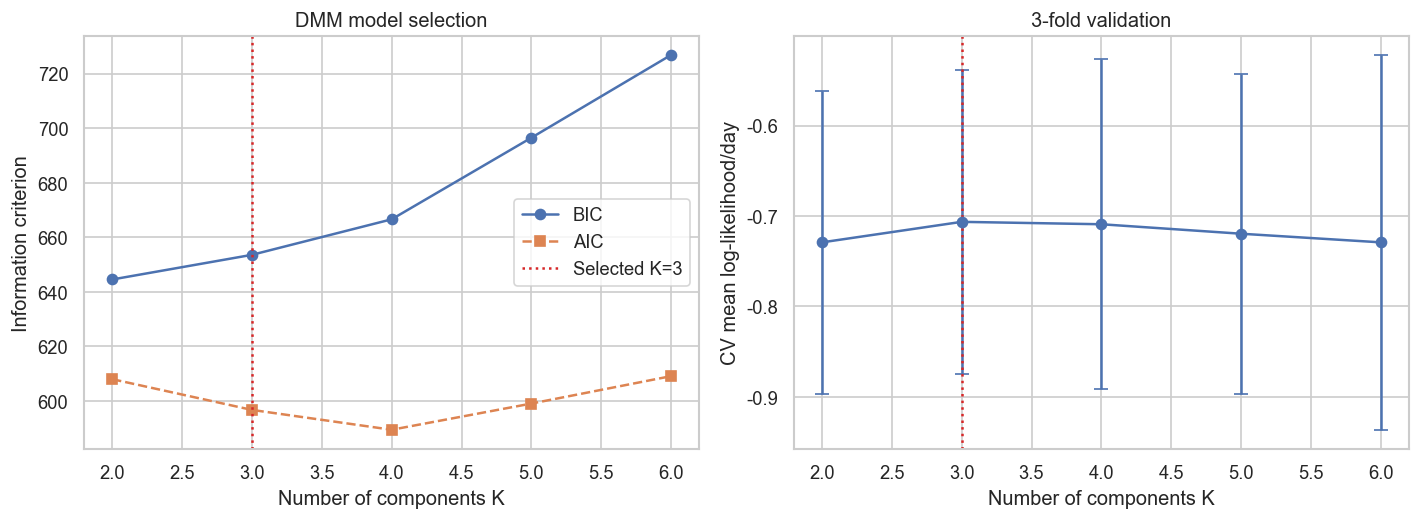

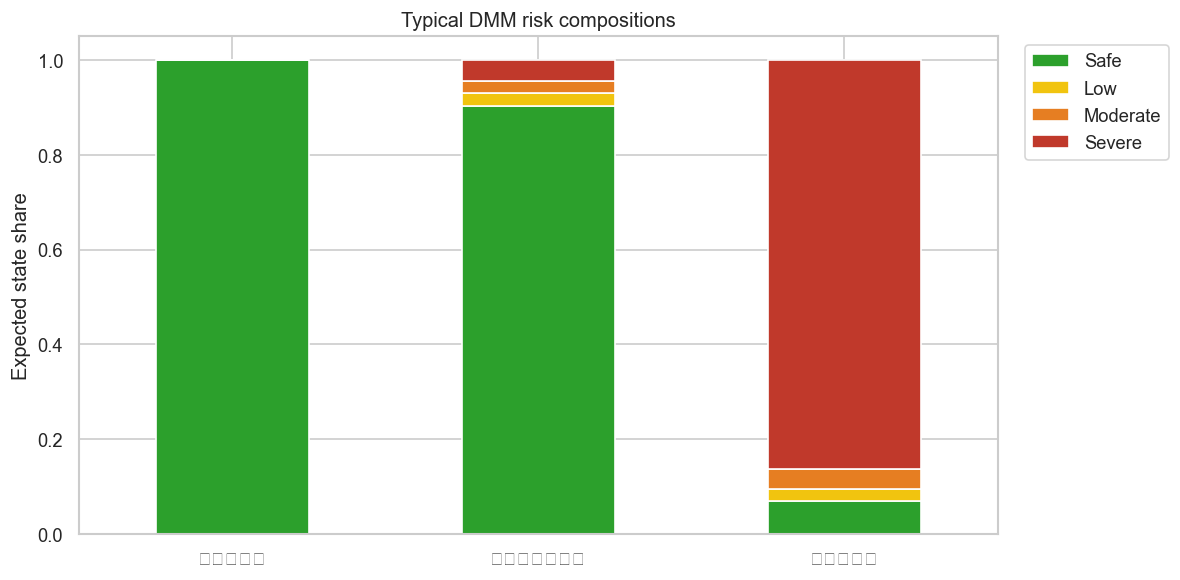

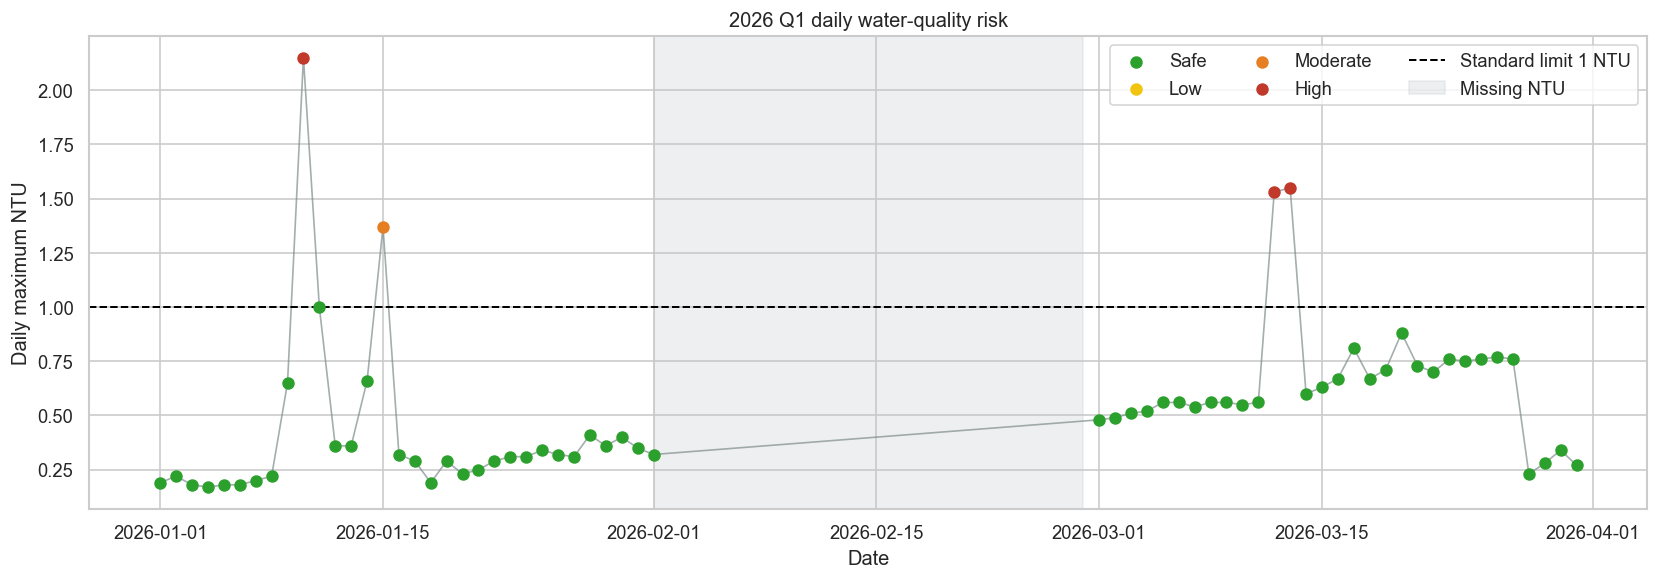

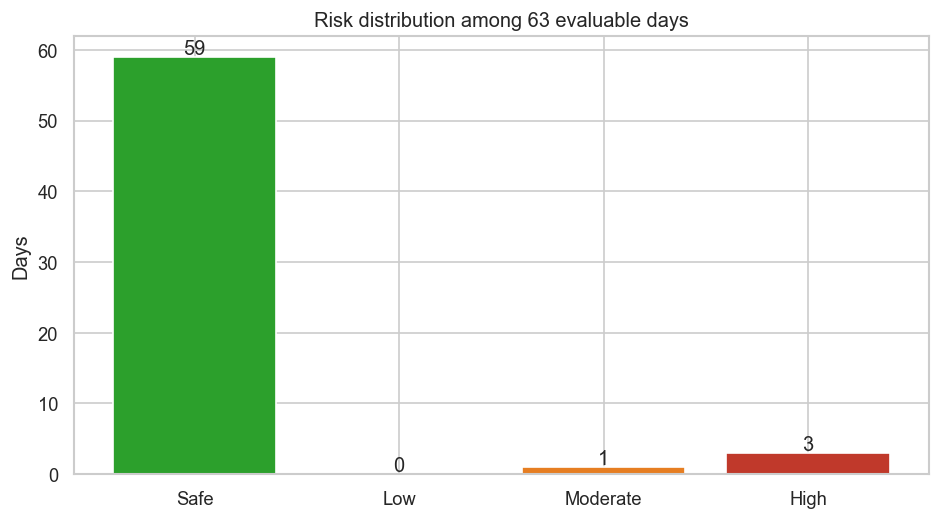

In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

# 1) K 选择
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(model_comparison["K"], model_comparison["BIC"], "o-", label="BIC")
axes[0].plot(model_comparison["K"], model_comparison["AIC"], "s--", label="AIC")
axes[0].axvline(selected_k, color="tab:red", linestyle=":", label=f"Selected K={selected_k}")
axes[0].set(xlabel="Number of components K", ylabel="Information criterion", title="DMM model selection")
axes[0].legend()

axes[1].errorbar(
    model_comparison["K"], model_comparison["CV_mean_loglik_per_day"],
    yerr=model_comparison["CV_std"], marker="o", capsize=4
)
axes[1].axvline(selected_k, color="tab:red", linestyle=":")
axes[1].set(xlabel="Number of components K", ylabel="CV mean log-likelihood/day", title="3-fold validation")
fig.tight_layout()
fig.savefig(FIG_DIR / "dmm_k_selection.png", bbox_inches="tight")
plt.show()

# 2) DMM 典型组成
profile_plot = cluster_profiles.set_index("pattern_name")[
    ["safe_share", "low_share", "mid_share", "high_share"]
]
ax = profile_plot.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#2ca02c", "#f1c40f", "#e67e22", "#c0392b"]
)
ax.set(ylabel="Expected state share", xlabel="", title="Typical DMM risk compositions")
ax.legend(["Safe", "Low", "Moderate", "Severe"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "dmm_cluster_profiles.png", bbox_inches="tight")
plt.show()

# 3) 2026Q1 日最大 NTU 与最终风险
colors = {"安全": "#2ca02c", "低风险": "#f1c40f", "中风险": "#e67e22", "高风险": "#c0392b"}
risk_labels_en = {"安全": "Safe", "低风险": "Low", "中风险": "Moderate", "高风险": "High"}
fig, ax = plt.subplots(figsize=(14, 5))
for risk in RISK_ORDER:
    part = valid_q1[valid_q1["final_risk"].eq(risk)]
    ax.scatter(
        part["DATE"], part["max_NTU"], s=42, color=colors[risk],
        label=risk_labels_en[risk], zorder=3
    )
ax.plot(valid_q1["DATE"], valid_q1["max_NTU"], color="#7f8c8d", linewidth=1, alpha=0.7)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Standard limit 1 NTU")
ax.axvspan(pd.Timestamp("2026-02-01"), pd.Timestamp("2026-02-28"), color="#bdc3c7", alpha=0.25, label="Missing NTU")
ax.set(ylabel="Daily maximum NTU", xlabel="Date", title="2026 Q1 daily water-quality risk")
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "q1_daily_risk.png", bbox_inches="tight")
plt.show()

# 4) 风险天数占比
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    [risk_labels_en[x] for x in q1_risk_summary["风险等级"]],
    q1_risk_summary["天数"],
    color=[colors[x] for x in RISK_ORDER]
)
for bar, value in zip(bars, q1_risk_summary["天数"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.4, str(value), ha="center")
ax.set(ylabel="Days", title=f"Risk distribution among {len(valid_q1)} evaluable days")
fig.tight_layout()
fig.savefig(FIG_DIR / "q1_risk_distribution.png", bbox_inches="tight")
plt.show()

## 13. 导出 Excel 与机器可读结果

In [14]:
excel_path = OUTPUT_DIR / "problem4_DMM_risk_assessment.xlsx"
json_path = OUTPUT_DIR / "problem4_DMM_summary.json"

rules_table = pd.DataFrame([
    ["安全", "exceed_count = 0", "所有有效观测点 NTU <= 1"],
    ["低风险", "exceed_ratio <= 20%, max_NTU <= 1.2, 连续超标点数 <= 2", "少量轻微且短时超标"],
    ["中风险", "有超标但不属于低风险或高风险", "较明显或持续性异常"],
    ["高风险", "exceed_ratio > 50%, 或 max_NTU > 1.5, 或连续超标点数 > 5", "严重或长时间异常"],
], columns=["风险等级", "规则", "解释"])

export_daily_cols = [
    "DATE", "n_points", "data_coverage", "is_complete_day",
    "mean_NTU", "max_NTU", "min_NTU", "std_NTU",
    "exceed_count", "exceed_ratio", "max_exceed_amp", "mean_exceed_amp",
    "max_continuous_exceed_points", "max_continuous_exceed_hours",
    "n_safe", "n_low", "n_mid", "n_high",
    "rule_risk", "dmm_cluster", "dmm_pattern", "dmm_implied_risk",
    "dmm_max_probability", "final_risk", "was_adjusted", "fusion_note"
] + [f"dmm_prob_cluster_{k}" for k in range(selected_k)]

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    audit.to_excel(writer, sheet_name="data_audit", index=False)
    ntu_distribution.to_excel(writer, sheet_name="NTU_distribution")
    data.to_excel(writer, sheet_name="point_level", index=False)
    daily[export_daily_cols].to_excel(writer, sheet_name="all_daily_results", index=False)
    q1.to_excel(writer, sheet_name="2026Q1_calendar", index=False)
    q1_coverage_summary.to_excel(writer, sheet_name="Q1_coverage", index=False)
    q1_risk_summary.to_excel(writer, sheet_name="Q1_risk_summary", index=False)
    march_results.to_excel(writer, sheet_name="March_daily", index=False)
    model_comparison.to_excel(writer, sheet_name="DMM_K_comparison", index=False)
    eligible.to_excel(writer, sheet_name="DMM_K_ranking", index=False)
    cluster_profiles.to_excel(writer, sheet_name="DMM_patterns", index=False)
    consistency.to_excel(writer, sheet_name="rule_DMM_consistency")
    daily.loc[daily["was_adjusted"], export_daily_cols].to_excel(
        writer, sheet_name="DMM_adjustments", index=False
    )
    rules_table.to_excel(writer, sheet_name="risk_rules", index=False)

summary_payload = {
    "selected_k": selected_k,
    "calendar_days_2026Q1": int(len(q1)),
    "evaluable_days_2026Q1": int(len(valid_q1)),
    "missing_days_2026Q1": int(q1["data_status"].eq("数据缺失").sum()),
    "risk_days": {
        row["风险等级"]: int(row["天数"])
        for _, row in q1_risk_summary.iterrows()
    },
    "adjusted_days_all_history": int(daily["was_adjusted"].sum()),
    "excel_output": str(excel_path),
}
json_path.write_text(
    json.dumps(summary_payload, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Excel 已保存：", excel_path)
print("摘要 JSON 已保存：", json_path)

Excel 已保存： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs/problem4_DMM_risk_assessment.xlsx
摘要 JSON 已保存： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs/problem4_DMM_summary.json


## 14. 最终摘要与关键结论

In [15]:
print("=" * 88)
print("A题第四问：规则 + DMM 水质风险评价完成")
print("=" * 88)
print(f"全部历史有效日期：{len(daily)} 天")
print(f"DMM 选择簇数：K = {selected_k}")
print(f"2026Q1 日历日：{len(q1)} 天")
print(f"2026Q1 有效评价日：{len(valid_q1)} 天")
print(f"2026Q1 缺失日：{q1['data_status'].eq('数据缺失').sum()} 天")
print("\n四类风险天数（分母为有效评价日）：")
for _, row in q1_risk_summary.iterrows():
    print(
        f"  {row['风险等级']}: {int(row['天数'])} 天, "
        f"{row['占有效评价日比例']:.2%}"
    )
print(f"\nDMM 辅助修正日期数（全部历史）：{daily['was_adjusted'].sum()} 天")
print("\n2026 年 3 月非安全日：")
display(
    march_results.loc[
        march_results["final_risk"].ne("安全"),
        ["DATE", "max_NTU", "exceed_ratio", "max_continuous_exceed_hours",
         "rule_risk", "dmm_pattern", "final_risk", "fusion_note"]
    ]
)

A题第四问：规则 + DMM 水质风险评价完成
全部历史有效日期：429 天
DMM 选择簇数：K = 3
2026Q1 日历日：90 天
2026Q1 有效评价日：63 天
2026Q1 缺失日：27 天

四类风险天数（分母为有效评价日）：
  安全: 59 天, 93.65%
  低风险: 0 天, 0.00%
  中风险: 1 天, 1.59%
  高风险: 3 天, 4.76%

DMM 辅助修正日期数（全部历史）：2 天

2026 年 3 月非安全日：


,DATE,max_NTU,exceed_ratio,max_continuous_exceed_hours,rule_risk,dmm_pattern,final_risk,fusion_note
70,2026-03-12,1.5300,0.1667,4.0000,高风险,持续中度异常型,高风险,规则高风险不下调
71,2026-03-13,1.5500,0.1667,4.0000,高风险,持续中度异常型,高风险,规则高风险不下调
